# FWI 3-Panel: GFDL-ESM4 vs MRI-ESM2-0 (Avg RH) vs MRI-ESM2-0 (Min RH)

Loads pre-computed annual FWI means from each model's cache (written by the respective `FWI_Compute.ipynb`) and produces a 3-panel time-series figure comparing all three model configurations across SSP scenarios.

**Study region:** Thailand (5.5–20.5°N, 97.5–105.5°E)  
**Models:** GFDL-ESM4 · MRI-ESM2-0 (hurs) · MRI-ESM2-0 (hursmin)  
**FWI source:** Quilcaille et al. (2023)

> Run each model's `FWI_Compute.ipynb` at least once before running this notebook.

In [2]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd


## 1  Cache paths & scenarios

Define the three cache directory paths (one per model) and the list of SSP scenarios to load from each cache.

In [4]:
GFDL_CACHE    = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/GFDL_ESM4/computed_means_GFDL-ESM4")
HURS_CACHE    = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")
HURSMIN_CACHE = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")

GFDL_SCENARIOS    = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]
HURS_SCENARIOS    = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp434", "ssp460", "ssp534", "ssp585"]
HURSMIN_SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp460", "ssp534", "ssp585"]


## 2  Load from cache

Define `load_fwi_cache(cache_dir, scenarios)` and load per-scenario FWI DataArrays for all three models from their respective NetCDF caches.

In [6]:
def load_fwi_cache(cache_dir: Path, scenarios: list) -> dict:
    """Return {scenario_key: DataArray(year)} from pre-computed NetCDF files."""
    out = {}
    for s in scenarios:
        f = cache_dir / f"fwi_{s}.nc"
        if f.exists():
            out[s] = xr.open_dataarray(f).load()
        else:
            print(f"  [warn] missing: {f}")
    return out

gfdl_fwi    = load_fwi_cache(GFDL_CACHE,    GFDL_SCENARIOS)
hurs_fwi    = load_fwi_cache(HURS_CACHE,    HURS_SCENARIOS)
hursmin_fwi = load_fwi_cache(HURSMIN_CACHE, HURSMIN_SCENARIOS)

print("GFDL    :", list(gfdl_fwi.keys()))
print("hurs    :", list(hurs_fwi.keys()))
print("hursmin :", list(hursmin_fwi.keys()))


GFDL    : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
hurs    : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534', 'ssp585']
hursmin : ['historical', 'ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp460', 'ssp534', 'ssp585']


## 3  Palette, labels & helpers

Define the Okabe-Ito colour palette, scenario display labels, and smoothing utility. Also define `_print_min_max` and `_print_mean_sd` summary helpers.

In [8]:
# ── Palette ───────────────────────────────────────────────────────────────────
color_blind_palette = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp434":     "#E6D600",
    "ssp460":     "#D55E00",
    "ssp534":     "#0072B2",
    "ssp585":     "#CC79A7",
}

SHORT_LABELS = {
    "historical": "Historical",
    "ssp119": "SSP1-1.9",  "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",  "ssp370": "SSP3-7.0",
    "ssp434": "SSP4-3.4",  "ssp460": "SSP4-6.0",
    "ssp534": "SSP5-3.4OS","ssp585": "SSP5-8.5",
}

LONG_LABELS = {
    "historical": "Historical to Present (1850–2015)",
    "ssp119": "SSP1-1.9 (“Sustainability — Very Low Emissions”)",
    "ssp126": "SSP1-2.6 (“Sustainability — Low Emissions”)",
    "ssp245": "SSP2-4.5 (“Middle of the Road — Moderate Emissions”)",
    "ssp370": "SSP3-7.0 (“Regional Rivalry — High Emissions”)",
    "ssp434": "SSP4-3.4 (“Inequality”)",
    "ssp460": "SSP4-6.0 (“Inequality — Medium Emissions”)",
    "ssp534": "SSP5-3.4OS (“Fossil-Fueled Dev. + Overshoot”)",
    "ssp585": "SSP5-8.5 (“Fossil-Fueled Development”)",
}

# Canonical scenario order for sorting
_SCENARIO_RANK = {s: i for i, s in enumerate(
    ["historical","ssp119","ssp126","ssp245","ssp370","ssp434","ssp460","ssp534","ssp585"]
)}

def _scenario_rank(key):    return _SCENARIO_RANK.get(key, 99)
def _long_label_for(key):   return LONG_LABELS.get(key, key)
def _color_for_label(key):  return color_blind_palette.get(key, "#000000")

def _apply_rolling(arr, window):
    if window and window > 1:
        return pd.Series(arr).rolling(window, center=True, min_periods=1).mean().values
    return arr

def _present_keys_in_order(*fwi_dicts):
    """Unique scenario keys present in any of the dicts, in canonical order."""
    seen = set()
    out  = []
    for d in fwi_dicts:
        for k in d:
            if k not in seen:
                seen.add(k)
                out.append(k)
    return sorted(out, key=_scenario_rank)


## 4  Plot functions

Define `_plot_panel(ax, fwi_dict, smooth_window)` — draws one model's time-series panel — and `plot_fwi_3panel(...)` — assembles the full 3-panel figure and saves to disk.

In [10]:
def _plot_panel(ax, fwi_dict: dict, smooth_window=None):
    """Plot time-series from cache dict {scenario: DataArray(year)}, sorted in canonical order."""
    for scen in sorted(fwi_dict, key=_scenario_rank):
        da    = fwi_dict[scen]
        years = da["year"].values
        vals  = _apply_rolling(da.values, smooth_window)
        ax.plot(years, vals, label=_long_label_for(scen), linewidth=1.2,
                alpha=0.95, color=_color_for_label(scen))
    ax.grid(True, alpha=0.5)
    ax.tick_params(labelsize=16)

def set_split_title(ax, left, right="", fontsize=19):
    ax.set_title(left, loc="left", fontsize=fontsize)
    if right:
        ax.text(1.0, 1.02, right, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=fontsize)


def plot_fwi_3panel(
    gfdl_fwi:    dict,
    hurs_fwi:    dict,
    hursmin_fwi: dict,
    smooth_window: int = 10,
    output_path:   str = "Pict/FWI_3panel_all_models.png",
):
    """
    Layout (Elsevier double-column 190 mm = 7.48 in, min font 8 pt):
      [0,0] GFDL-ESM4              [0,1] SSP legend
      [1,0] MRI-ESM2-0 Avg RH      [1,1] MRI-ESM2-0 Min RH
    sharey=True across all panels.
    """
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(7.48, 3.3), sharey=True)
    axG   = axes[0, 0]
    axSSP = axes[0, 1]
    axH   = axes[1, 0]
    axMIN = axes[1, 1]

    # ── [0,0] GFDL-ESM4 ───────────────────────────────────────────────────────
    _plot_panel(axG, gfdl_fwi, smooth_window)
    set_split_title(axG, "a) GFDL-ESM4 Avg RH", "")
    axG.set_ylabel("FWI", fontsize=19)

    # ── [0,1] SSP Legend ──────────────────────────────────────────────────────
    axSSP.set_title("SSP", fontsize=19, loc="left")
    axSSP.axis("off")
    present = _present_keys_in_order(gfdl_fwi, hurs_fwi, hursmin_fwi)
    handles = []
    legend_texts = []
    for k in present:
        line, = axSSP.plot([], [], color=_color_for_label(k), linewidth=2.0)
        handles.append(line)
        legend_texts.append(SHORT_LABELS.get(k, k))
    axSSP.legend(handles, legend_texts, loc="upper left", frameon=False, fontsize=13, ncol=1)

    # ── [1,0] MRI-ESM2-0 Avg RH (hurs) ───────────────────────────────────────
    _plot_panel(axH, hurs_fwi, smooth_window)
    set_split_title(axH, "b) MRI-ESM2-0 Avg RH", "")
    axH.set_ylabel("FWI", fontsize=19)

    # ── [1,1] MRI-ESM2-0 Min RH (hursmin) ────────────────────────────────────
    _plot_panel(axMIN, hursmin_fwi, smooth_window)
    set_split_title(axMIN, "c) MRI-ESM2-0 Min RH", "")

    # ── Shared x-axis formatting ───────────────────────────────────────────────
    years = [1850, 1900, 1950, 2000, 2050, 2100]
    for ax in [axG, axH, axMIN]:
        ax.set_xlim(1850, 2100)
        ax.set_ylim(bottom=15)
        ax.set_xticks(years)
        ax.set_xticklabels([str(y) for y in years])

    plt.subplots_adjust(left=0.08, right=1.5, bottom=0.1, top=1.7,
                        wspace=0.15, hspace=0.35)
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    print(f"Saved → {output_path}")
    plt.show()


## 5  Run

Call `plot_fwi_3panel` with the loaded FWI dictionaries to produce and save the figure. Optionally print min/max and mean ± SD summaries per model.

Saved → Pict/FWI_3panel_all_models.png


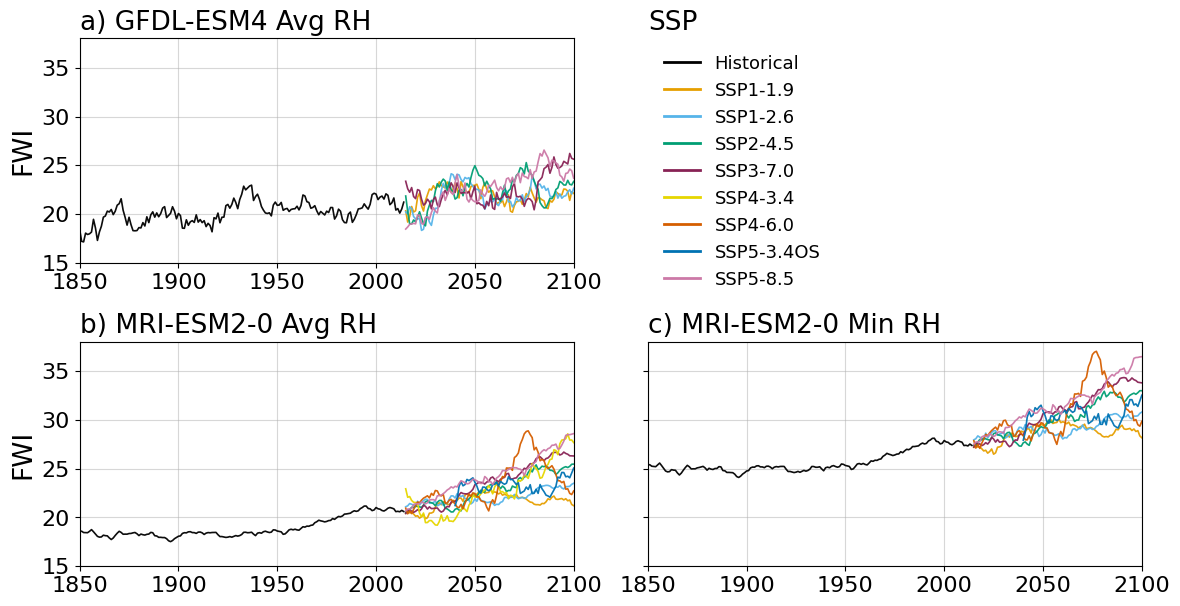

In [12]:
plot_fwi_3panel(
    gfdl_fwi      = gfdl_fwi,
    hurs_fwi      = hurs_fwi,
    hursmin_fwi   = hursmin_fwi,
    smooth_window = 10,
    output_path   = "Pict/FWI_3panel_all_models.png",
)


Saved → Pict/FWI_3panel_all_models.png


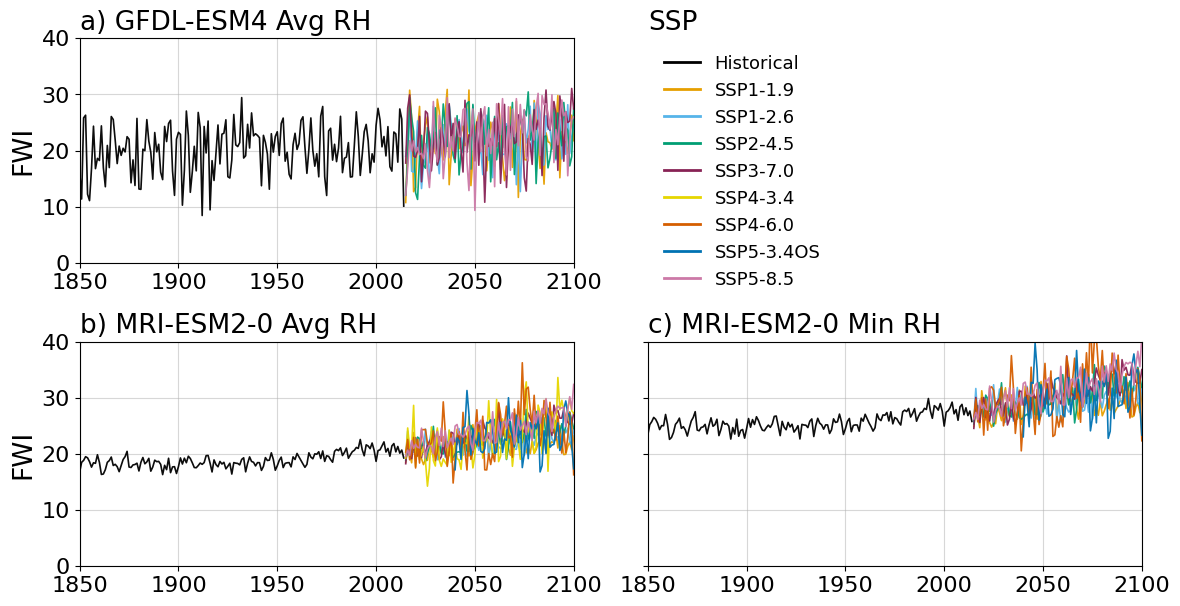

In [13]:
def plot_fwi_3panel(
    gfdl_fwi:    dict,
    hurs_fwi:    dict,
    hursmin_fwi: dict,
    smooth_window: int = 10,
    output_path:   str = "Pict/FWI_3panel_all_models.png",
):
    """
    Layout (Elsevier double-column 190 mm = 7.48 in, min font 8 pt):
      [0,0] GFDL-ESM4              [0,1] SSP legend
      [1,0] MRI-ESM2-0 Avg RH      [1,1] MRI-ESM2-0 Min RH
    sharey=True across all panels.
    """
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(7.48, 3.3), sharey=True)
    axG   = axes[0, 0]
    axSSP = axes[0, 1]
    axH   = axes[1, 0]
    axMIN = axes[1, 1]

    # ── [0,0] GFDL-ESM4 ───────────────────────────────────────────────────────
    _plot_panel(axG, gfdl_fwi, smooth_window)
    set_split_title(axG, "a) GFDL-ESM4 Avg RH", "")
    axG.set_ylabel("FWI", fontsize=19)

    # ── [0,1] SSP Legend ──────────────────────────────────────────────────────
    axSSP.set_title("SSP", fontsize=19, loc="left")
    axSSP.axis("off")
    present = _present_keys_in_order(gfdl_fwi, hurs_fwi, hursmin_fwi)
    handles = []
    legend_texts = []
    for k in present:
        line, = axSSP.plot([], [], color=_color_for_label(k), linewidth=2.0)
        handles.append(line)
        legend_texts.append(SHORT_LABELS.get(k, k))
    axSSP.legend(handles, legend_texts, loc="upper left", frameon=False, fontsize=13, ncol=1)

    # ── [1,0] MRI-ESM2-0 Avg RH (hurs) ───────────────────────────────────────
    _plot_panel(axH, hurs_fwi, smooth_window)
    set_split_title(axH, "b) MRI-ESM2-0 Avg RH", "")
    axH.set_ylabel("FWI", fontsize=19)

    # ── [1,1] MRI-ESM2-0 Min RH (hursmin) ────────────────────────────────────
    _plot_panel(axMIN, hursmin_fwi, smooth_window)
    set_split_title(axMIN, "c) MRI-ESM2-0 Min RH", "")

    # ── Shared x-axis formatting ───────────────────────────────────────────────
    years = [1850, 1900, 1950, 2000, 2050, 2100]
    for ax in [axG, axH, axMIN]:
        ax.set_xlim(1850, 2100)
        ax.set_ylim(0, 40)
        ax.set_xticks(years)
        ax.set_xticklabels([str(y) for y in years])

    plt.subplots_adjust(left=0.08, right=1.5, bottom=0.1, top=1.7,
                        wspace=0.15, hspace=0.35)
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    print(f"Saved → {output_path}")
    plt.show()

plot_fwi_3panel(
    gfdl_fwi      = gfdl_fwi,
    hurs_fwi      = hurs_fwi,
    hursmin_fwi   = hursmin_fwi,
    smooth_window = 1,
    output_path   = "Pict/FWI_3panel_all_models.png",
)


In [14]:
def _print_min_max(label, data_dict):
    print(f"\n=== {label} ===")
    for k, v in data_dict.items():
        arr = np.array(v)
        print(f"{k}: min = {np.nanmin(arr):.2f}, max = {np.nanmax(arr):.2f}")

# Print stats for each panel
_print_min_max("GFDL-ESM4 Avg RH", gfdl_fwi)
_print_min_max("MRI-ESM2-0 Avg RH (hurs)", hurs_fwi)
_print_min_max("MRI-ESM2-0 Min RH (hursmin)", hursmin_fwi)


=== GFDL-ESM4 Avg RH ===
historical: min = 8.45, max = 29.44
ssp119: min = 10.76, max = 30.90
ssp126: min = 12.70, max = 28.48
ssp245: min = 11.31, max = 30.46
ssp370: min = 10.81, max = 31.07
ssp585: min = 9.36, max = 30.19

=== MRI-ESM2-0 Avg RH (hurs) ===
historical: min = 16.32, max = 22.57
ssp119: min = 18.11, max = 25.22
ssp126: min = 18.96, max = 24.61
ssp245: min = 18.64, max = 27.93
ssp370: min = 18.26, max = 28.97
ssp434: min = 14.26, max = 33.61
ssp460: min = 14.82, max = 36.24
ssp534: min = 16.80, max = 31.29
ssp585: min = 19.28, max = 32.37

=== MRI-ESM2-0 Min RH (hursmin) ===
historical: min = 22.59, max = 29.86
ssp119: min = 24.67, max = 32.90
ssp126: min = 25.68, max = 32.38
ssp245: min = 24.94, max = 35.90
ssp370: min = 24.55, max = 37.46
ssp460: min = 20.54, max = 45.58
ssp534: min = 22.78, max = 39.72
ssp585: min = 25.66, max = 40.92


In [15]:
def _print_mean_sd(label, data_dict):
    print(f"\n=== {label} (mean ± SD) ===")
    for k, v in data_dict.items():
        arr = np.array(v)
        mean = np.nanmean(arr)
        sd   = np.nanstd(arr)
        print(f"{k}: {mean:.2f} ± {sd:.2f}")

_print_mean_sd("GFDL-ESM4 Avg RH", gfdl_fwi)
_print_mean_sd("MRI-ESM2-0 Avg RH (hurs)", hurs_fwi)
_print_mean_sd("MRI-ESM2-0 Min RH (hursmin)", hursmin_fwi)


=== GFDL-ESM4 Avg RH (mean ± SD) ===
historical: 20.19 ± 4.39
ssp119: 21.89 ± 4.51
ssp126: 21.82 ± 3.93
ssp245: 22.36 ± 4.36
ssp370: 22.53 ± 4.43
ssp585: 22.61 ± 4.76

=== MRI-ESM2-0 Avg RH (hurs) (mean ± SD) ===
historical: 18.93 ± 1.31
ssp119: 21.67 ± 1.67
ssp126: 22.09 ± 1.49
ssp245: 22.92 ± 2.22
ssp370: 23.55 ± 2.54
ssp434: 22.84 ± 4.16
ssp460: 23.36 ± 3.95
ssp534: 23.21 ± 3.27
ssp585: 24.32 ± 2.70

=== MRI-ESM2-0 Min RH (hursmin) (mean ± SD) ===
historical: 25.68 ± 1.48
ssp119: 28.69 ± 2.02
ssp126: 29.14 ± 1.83
ssp245: 30.10 ± 2.62
ssp370: 30.76 ± 2.95
ssp460: 30.61 ± 4.66
ssp534: 30.46 ± 3.92
ssp585: 31.65 ± 3.14
